# PaySim Fraud Detection Pipeline

This notebook implements a complete end-to-end fraud detection pipeline on the PaySim dataset.

**Pipeline Structure:**

| # | Section | Description |
|---|---------|-------------|
| 1 | **Setup & Data Loading** | Imports, configuration, load raw data |
| 2 | **Exploratory Data Analysis** | Understand the data through 7 key findings |
| 3 | **Feature Engineering** | Transform EDA insights into ML features |
| 4 | **Data Preparation** | Train/test split and export |
| 5 | **Modelling** | Train 4 models (LR, XGBoost, Isolation Forest, SVM) |
| 6 | **Model Evaluation & Comparison** | Compare all models side-by-side |
| 7 | **Model Export** | Save best models as `.joblib` for deployment |

---
# 1. Setup & Data Loading
---

## 1.1 Import Libraries

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

# Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    recall_score,
    precision_score,
)

# XGBoost
try:
    import xgboost as xgb
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'xgboost'])
    import xgboost as xgb

# Plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries loaded successfully.')
print(f'  XGBoost version: {xgb.__version__}')

All libraries loaded successfully.
  XGBoost version: 3.2.0


## 1.2 Load Data

In [59]:
# Dynamic path resolution — works on any machine
DATA_DIR = Path().resolve()  # notebook's directory
DATA_FILE = DATA_DIR / 'Synthetic_Financial_datasets_log.csv'

df = pd.read_csv(DATA_FILE)
print(f'Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')
df.head()

Dataset: 6,362,620 rows, 11 columns


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


---
# 2. Exploratory Data Analysis
---

**Column Reference:**

| Column | Meaning | Example |
|--------|---------|--------|
| step | Hour of simulation (1 step = 1 hour) | 1 |
| type | Transaction type | PAYMENT, TRANSFER, CASH_OUT, DEBIT, CASH_IN |
| amount | Transaction amount | 9839.64 |
| nameOrig | Sender account ID (C = Customer) | C1231006815 |
| oldbalanceOrg | Sender balance BEFORE transaction | 170136.0 |
| newbalanceOrig | Sender balance AFTER transaction | 160296.36 |
| nameDest | Receiver account ID (C = Customer, M = Merchant) | M1979787155 |
| oldbalanceDest | Receiver balance BEFORE transaction | 0.0 |
| newbalanceDest | Receiver balance AFTER transaction | 0.0 |
| isFraud | Is this fraud? (0 = No, 1 = Yes) | 0 |
| isFlaggedFraud | Was it flagged by original system? | 0 |

## 1.2 Data Shape & Types

In [60]:
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print()
df.info()

Rows: 6,362,620
Columns: 11

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


**Key observations:**
- All Non-Null counts equal the total rows -> **no missing values**
- type, nameOrig, nameDest are `object` (text), rest are numeric
- This is simulated data (PaySim), so it's inherently clean

## 1.3 Basic Statistics

In [61]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


**Key observations:**
- `amount`: mean ~180K but max ~92M -> extreme right skew
- `isFraud`: mean is tiny (~0.001) -> very few fraud cases
- `isFlaggedFraud`: mean is nearly 0 -> original flag system barely works

## 1.4 Fraud Distribution (Class Imbalance)

In [62]:
fraud_counts = df['isFraud'].value_counts()
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100

print('Fraud counts:')
print(fraud_counts)
print()
print('Fraud percentage:')
print(fraud_pct.round(4))

Fraud counts:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud percentage:
isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64


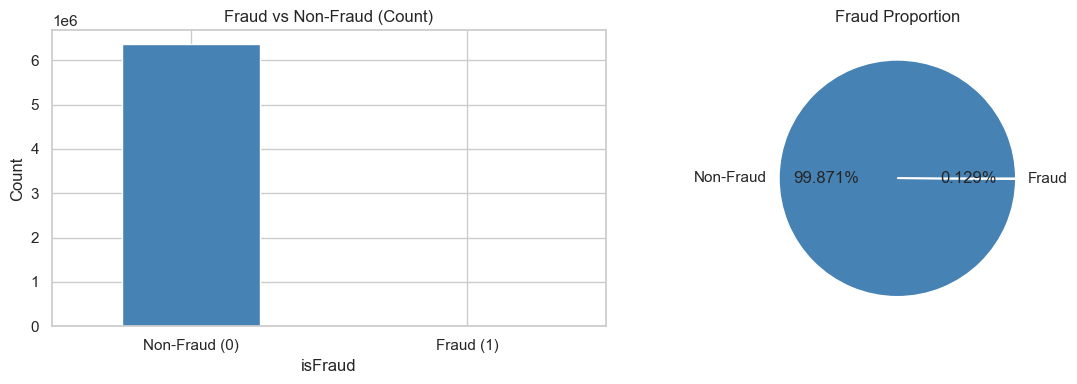

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
fraud_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Fraud vs Non-Fraud (Count)')
axes[0].set_xticklabels(['Non-Fraud (0)', 'Fraud (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(fraud_counts,
            labels=['Non-Fraud', 'Fraud'],
            autopct='%1.3f%%',
            colors=['steelblue', 'tomato'])
axes[1].set_title('Fraud Proportion')

plt.tight_layout()
plt.show()

**Finding 1: Extreme class imbalance**
- Fraud is only ~0.13% of all transactions
- A model that always predicts "not fraud" gets 99.87% accuracy
- Therefore we CANNOT use accuracy as our metric -> use Recall, Precision, F1, AUC instead

## 1.5 Transaction Types

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


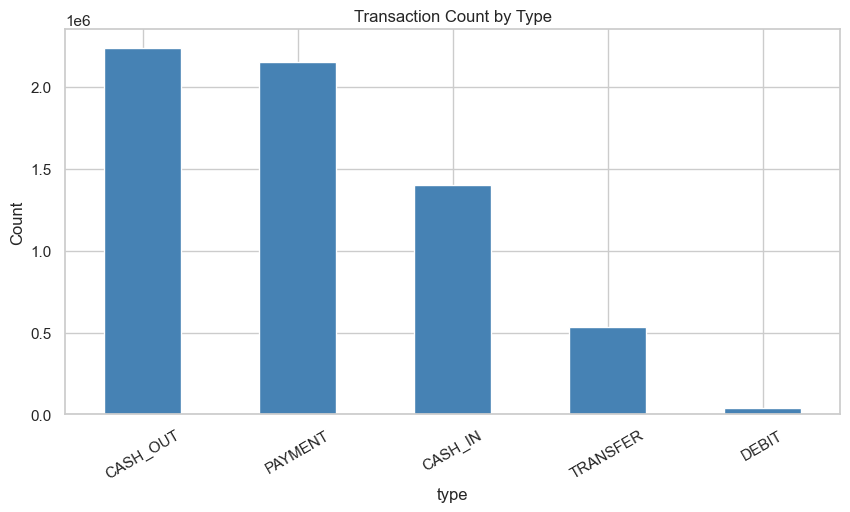

In [64]:
type_counts = df['type'].value_counts()
print(type_counts)

type_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Transaction Count by Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

## 1.6 Fraud Rate by Transaction Type

Fraud rate (%) by type:
type
CASH_IN     0.0000
CASH_OUT    0.1840
DEBIT       0.0000
PAYMENT     0.0000
TRANSFER    0.7688
Name: isFraud, dtype: float64



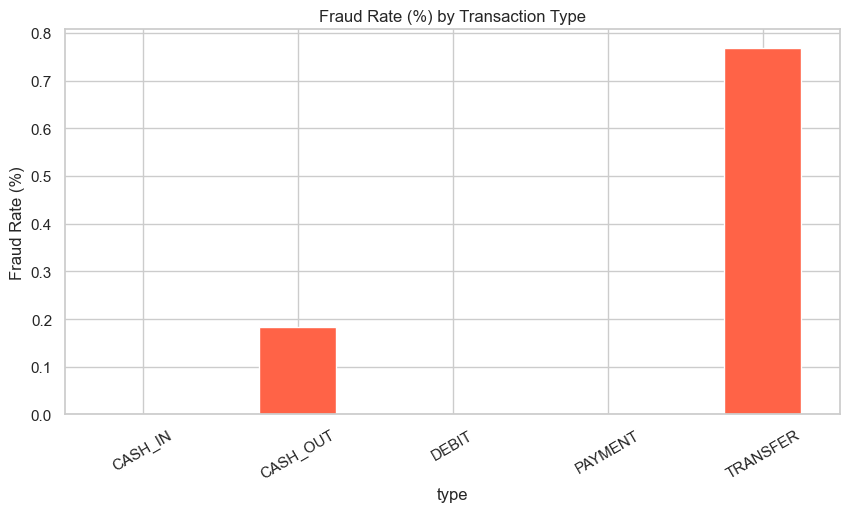

In [65]:
fraud_rate_by_type = df.groupby('type')['isFraud'].mean() * 100

print('Fraud rate (%) by type:')
print(fraud_rate_by_type.round(4))
print()

fraud_rate_by_type.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Fraud Rate (%) by Transaction Type')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=30)
plt.show()

**Finding 2: Fraud only occurs in TRANSFER and CASH_OUT**
- PAYMENT, CASH_IN, DEBIT have 0% fraud rate
- This is a critical insight for feature engineering

## 1.7 Amount Distribution: Fraud vs Non-Fraud

In [66]:
non_fraud = df[df['isFraud'] == 0]
fraud = df[df['isFraud'] == 1]

print(f'Non-fraud: {len(non_fraud):,} transactions')
print(f'Fraud:     {len(fraud):,} transactions')

Non-fraud: 6,354,407 transactions
Fraud:     8,213 transactions


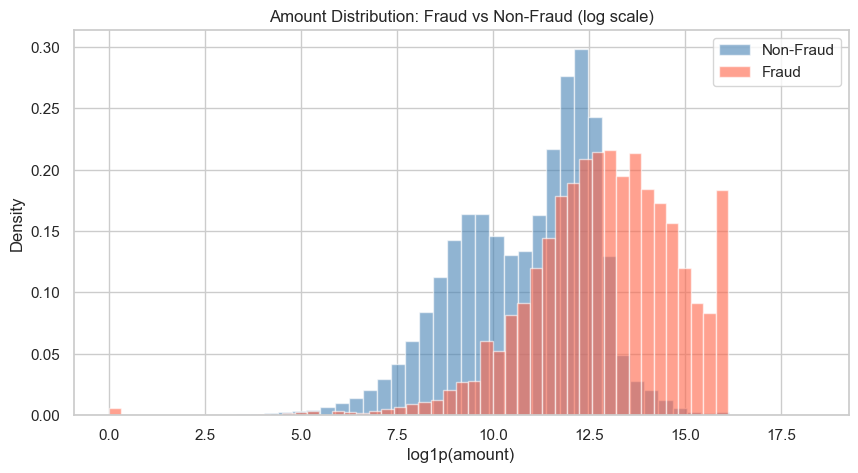

In [67]:
# Histogram using log scale (amount ranges 0 to 92M, log compresses it for visualization)
plt.figure(figsize=(10, 5))
plt.hist(np.log1p(non_fraud['amount']), bins=50, alpha=0.6, label='Non-Fraud', color='steelblue', density=True)
plt.hist(np.log1p(fraud['amount']), bins=50, alpha=0.6, label='Fraud', color='tomato', density=True)
plt.xlabel('log1p(amount)')
plt.ylabel('Density')
plt.title('Amount Distribution: Fraud vs Non-Fraud (log scale)')
plt.legend()
plt.show()

In [68]:
print('=== Non-Fraud Amount Stats ===')
print(non_fraud['amount'].describe())
print()
print('=== Fraud Amount Stats ===')
print(fraud['amount'].describe())

=== Non-Fraud Amount Stats ===
count    6.354407e+06
mean     1.781970e+05
std      5.962370e+05
min      1.000000e-02
25%      1.336840e+04
50%      7.468472e+04
75%      2.083648e+05
max      9.244552e+07
Name: amount, dtype: float64

=== Fraud Amount Stats ===
count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64


**Finding 3: Fraud transactions have significantly higher amounts**
- Fraud mean ~1.5M vs Non-fraud mean ~180K
- But there is substantial overlap, so amount alone is not sufficient

## 1.8 Balance Error Analysis

In [69]:
# If normal: newbalanceOrig + amount - oldbalanceOrg = 0
df['_errorOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['_errorDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

print('Balance error stats by fraud label:')
print(df.groupby('isFraud')[['_errorOrig', '_errorDest']].agg(['mean', 'median']).round(2))

Balance error stats by fraud label:
        _errorOrig           _errorDest         
              mean    median       mean   median
isFraud                                         
0        201338.56  69049.31   54692.23  3500.68
1         10692.33      0.00  732509.30  2231.46


**Finding 4 (Counter-intuitive): Fraud has balance error close to 0, non-fraud has larger errors**

Why?
- Fraud drains the full account: `amount = oldbalanceOrg`, so the math checks out (error = 0)
- Non-fraud has concurrent transactions in the simulator, causing balance snapshot mismatches

This means: **error near zero + balance drained = strong fraud signal**

## 1.9 Balance Drain Analysis

In [70]:
# Account drained: had money before AND zero after
df['_drain'] = ((df['oldbalanceOrg'] > 0) & (df['newbalanceOrig'] == 0)).astype(int)

print('Balance drain proportion by fraud label:')
print(df.groupby('isFraud')['_drain'].mean().round(4))

Balance drain proportion by fraud label:
isFraud
0    0.2380
1    0.9755
Name: _drain, dtype: float64


**Finding 5: Account drain is far more common in fraud transactions**

## 1.10 Time Patterns

Time range: step 1 to step 743
Approximately 31 days


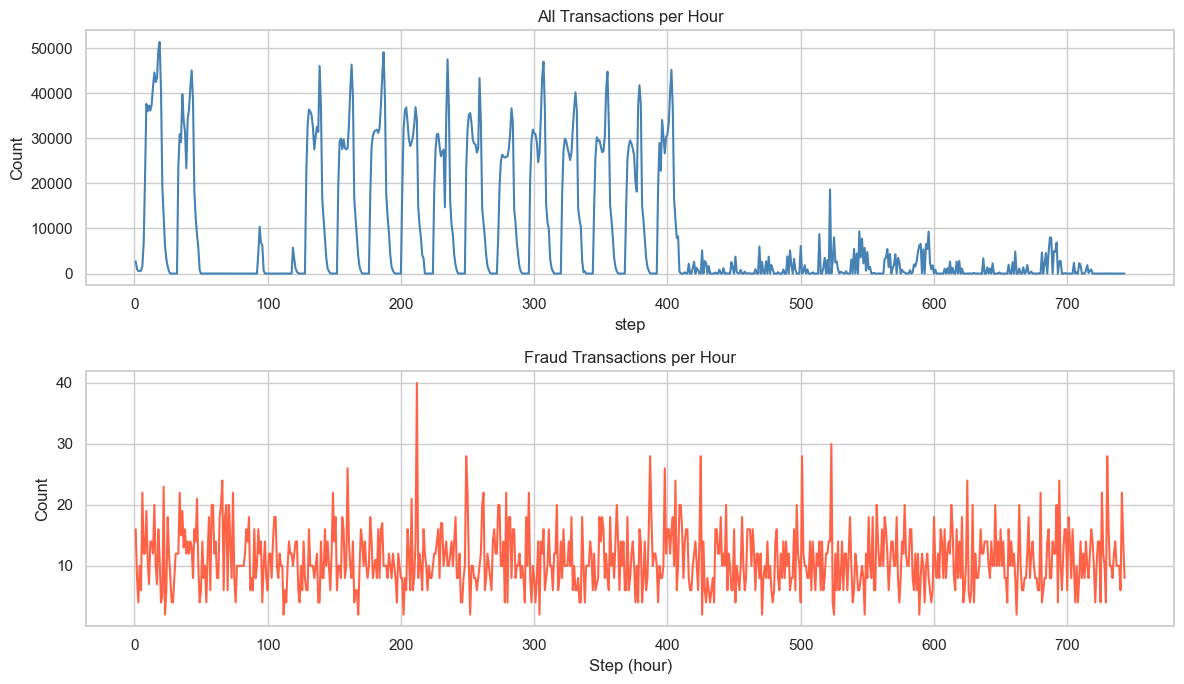

In [71]:
print(f'Time range: step {df["step"].min()} to step {df["step"].max()}')
print(f'Approximately {df["step"].max() / 24:.0f} days')

txn_per_hour = df.groupby('step').size()
fraud_per_hour = df[df['isFraud'] == 1].groupby('step').size()

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

txn_per_hour.plot(ax=axes[0], color='steelblue')
axes[0].set_title('All Transactions per Hour')
axes[0].set_ylabel('Count')

fraud_per_hour.plot(ax=axes[1], color='tomato')
axes[1].set_title('Fraud Transactions per Hour')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Step (hour)')

plt.tight_layout()
plt.show()

**Finding 6: Transaction volume has a 24-hour cycle, but fraud does NOT concentrate at specific hours**

Time features will be low priority.

## 1.11 Correlation Heatmap

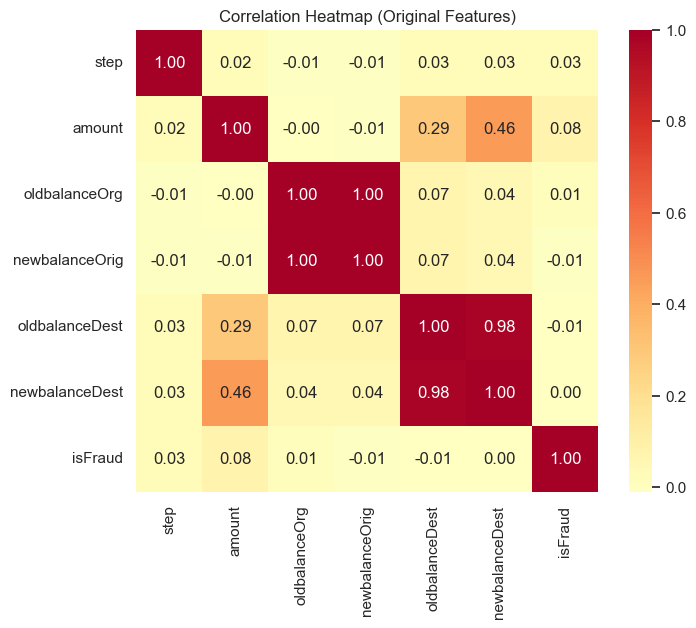

In [72]:
num_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
            'oldbalanceDest', 'newbalanceDest', 'isFraud']

corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0, square=True)
plt.title('Correlation Heatmap (Original Features)')
plt.show()

## 1.12 isFlaggedFraud Effectiveness

In [73]:
ct = pd.crosstab(df['isFraud'], df['isFlaggedFraud'], margins=True)
print(ct)

print()
total_fraud = df['isFraud'].sum()
flagged_and_fraud = ((df['isFraud'] == 1) & (df['isFlaggedFraud'] == 1)).sum()

print(f'Total actual fraud: {total_fraud:,}')
print(f'Flagged AND actually fraud: {flagged_and_fraud}')
print(f'Recall: {flagged_and_fraud / total_fraud * 100:.2f}%')
print(f'-> Original system missed {100 - flagged_and_fraud / total_fraud * 100:.2f}% of all fraud')

isFlaggedFraud        0   1      All
isFraud                             
0               6354407   0  6354407
1                  8197  16     8213
All             6362604  16  6362620

Total actual fraud: 8,213
Flagged AND actually fraud: 16
Recall: 0.19%
-> Original system missed 99.81% of all fraud


**Finding 7: isFlaggedFraud is essentially useless (0.2% recall)**

This column will be dropped. It cannot be used as a feature (data leakage risk) and provides no value.

## 1.13 EDA Summary

| # | Finding | Implication for Feature Engineering |
|---|---------|------------------------------------|
| 1 | Fraud is 0.13% of data (extreme imbalance) | Use class_weight='balanced', evaluate with Recall/F1/AUC |
| 2 | Fraud only in TRANSFER and CASH_OUT | Create is_transfer, is_cashout binary features |
| 3 | Fraud amounts are larger (~1.5M vs ~180K) | Use log_amount and amountToBalanceRatio |
| 4 | Balance error near 0 indicates fraud | Create errorBalance features + near-zero flags |
| 5 | Account drain is common in fraud | Create balanceDrain binary feature |
| 6 | Time has weak signal for fraud | Keep hour_of_day but low priority |
| 7 | isFlaggedFraud is useless | Drop this column |

---
# 3. Feature Engineering
---

## 2.0 Clean Up Temporary EDA Columns & Drop Useless Columns

In [74]:
# Drop temporary EDA columns
df = df.drop(columns=['_errorOrig', '_errorDest', '_drain'], errors='ignore')

# Drop useless columns (Finding 7 + account IDs)
df = df.drop(columns=['isFlaggedFraud', 'nameOrig', 'nameDest'])

print(f'After cleanup: {df.shape[1]} columns')
print(f'Remaining: {df.columns.tolist()}')

After cleanup: 8 columns
Remaining: ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']


## 2.1 Transaction Type Encoding

**Based on Finding 2:** Fraud only occurs in TRANSFER and CASH_OUT.

We create two binary columns. The other 3 types (PAYMENT, DEBIT, CASH_IN) all map to (0, 0)
since their fraud rate is 0% and their differences are irrelevant for fraud detection.

In [75]:
df['is_transfer'] = (df['type'] == 'TRANSFER').astype(int)
df['is_cashout']  = (df['type'] == 'CASH_OUT').astype(int)
df = df.drop(columns=['type'])

print('is_transfer distribution:')
print(df['is_transfer'].value_counts())
print()
print('is_cashout distribution:')
print(df['is_cashout'].value_counts())

is_transfer distribution:
is_transfer
0    5829711
1     532909
Name: count, dtype: int64

is_cashout distribution:
is_cashout
0    4125120
1    2237500
Name: count, dtype: int64


## 2.2 Balance Error Features

**Based on Finding 4:** Fraud transactions have balance error close to 0 (counter-intuitive).

Normal transaction: `oldbalanceOrg - amount = newbalanceOrig` (error = 0).
Fraud drains the full balance, so `amount = oldbalanceOrg` and the math checks out.

In [76]:
# Sender balance error
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']

# Receiver balance error
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

print('errorBalanceOrig by fraud label:')
print(df.groupby('isFraud')['errorBalanceOrig'].describe()[['mean', '50%']].round(2))
print()
print('errorBalanceDest by fraud label:')
print(df.groupby('isFraud')['errorBalanceDest'].describe()[['mean', '50%']].round(2))

errorBalanceOrig by fraud label:
              mean       50%
isFraud                     
0        201338.56  69049.31
1         10692.33      0.00

errorBalanceDest by fraud label:
              mean      50%
isFraud                    
0         54692.23  3500.68
1        732509.30  2231.46


## 2.3 Error-Near-Zero Flags

**Based on Finding 4:** error close to 0 is a fraud signal.

We use `abs() < 1` instead of `== 0` to handle floating-point precision issues
(e.g. `0.1 + 0.2 = 0.30000000000000004`).

In [77]:
df['errorIsSmallOrig'] = (df['errorBalanceOrig'].abs() < 1).astype(int)
df['errorIsSmallDest'] = (df['errorBalanceDest'].abs() < 1).astype(int)

print('errorIsSmallOrig proportion (fraud vs non-fraud):')
print(df.groupby('isFraud')['errorIsSmallOrig'].mean().round(4))
print()
print('errorIsSmallDest proportion (fraud vs non-fraud):')
print(df.groupby('isFraud')['errorIsSmallDest'].mean().round(4))

errorIsSmallOrig proportion (fraud vs non-fraud):
isFraud
0    0.2130
1    0.9945
Name: errorIsSmallOrig, dtype: float64

errorIsSmallDest proportion (fraud vs non-fraud):
isFraud
0    0.3989
1    0.4842
Name: errorIsSmallDest, dtype: float64


## 2.4 Balance Drain Detection

**Based on Finding 5:** Fraud transactions frequently drain the sender's account to zero.

Condition: had money before (`oldbalanceOrg > 0`) AND zero after (`newbalanceOrig == 0`).

In [78]:
df['balanceDrain'] = ((df['oldbalanceOrg'] > 0) & (df['newbalanceOrig'] == 0)).astype(int)

print('balanceDrain proportion:')
print(df.groupby('isFraud')['balanceDrain'].mean().round(4))

balanceDrain proportion:
isFraud
0    0.2380
1    0.9755
Name: balanceDrain, dtype: float64


## 2.5 Amount-to-Balance Ratio

**Based on Finding 3 & 5:** Fraud amount tends to equal the full balance.

The ratio is more informative than raw amount:
- Ratio close to 1.0 = drained nearly the entire account
- Ratio close to 0 = small relative to balance

In [79]:
# +1 to avoid division by zero
df['amountToBalanceRatio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

print('amountToBalanceRatio stats:')
print(df.groupby('isFraud')['amountToBalanceRatio'].describe()[['mean', '50%', 'max']].round(2))

amountToBalanceRatio stats:
             mean   50%          max
isFraud                             
0        70764.32  6.51  92445516.64
1         1161.97  1.00   1933920.80


## 2.6 Receiver Arrival Error

If 1M was transferred but the receiver's balance only increased by 500K, something is wrong.

`destError = |actual increase - expected increase| = |(newbalanceDest - oldbalanceDest) - amount|`

In [80]:
df['destError'] = ((df['newbalanceDest'] - df['oldbalanceDest']) - df['amount']).abs()

print('destError stats:')
print(df.groupby('isFraud')['destError'].describe()[['mean', '50%']].round(2))

destError stats:
              mean      50%
isFraud                    
0         92756.96  5123.10
1        745138.59  9511.69


## 2.7 Log-Transformed Amount

**Based on Finding 3:** Amount ranges from 0 to 92M with extreme right skew.

`log1p(x) = log(x + 1)` compresses the distribution, making it easier for models to learn.

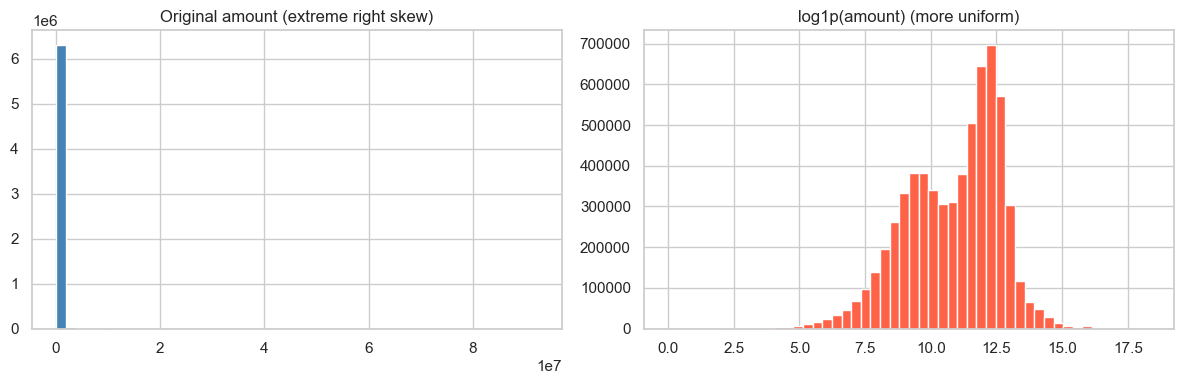

In [81]:
df['log_amount'] = np.log1p(df['amount'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['amount'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Original amount (extreme right skew)')
axes[1].hist(df['log_amount'], bins=50, color='tomato', edgecolor='white')
axes[1].set_title('log1p(amount) (more uniform)')
plt.tight_layout()
plt.show()

## 2.8 Time Feature (Low Priority)

**Based on Finding 6:** 24-hour cycle exists but fraud doesn't concentrate at specific hours.

In [82]:
df['hour_of_day'] = df['step'] % 24

print(f'hour_of_day range: {df["hour_of_day"].min()} ~ {df["hour_of_day"].max()}')

hour_of_day range: 0 ~ 23


---
# Part 3: Validation, Split & Export
---

---
# 4. Data Preparation
---

## 3.1 Final Feature Set Review

In [83]:
feature_cols = [
    # Transaction type (Finding 2)
    'is_transfer',
    'is_cashout',
    # Balance anomaly - core features (Finding 4 & 5)
    'errorBalanceOrig',
    'errorBalanceDest',
    'errorIsSmallOrig',
    'errorIsSmallDest',
    'balanceDrain',
    # Amount (Finding 3)
    'amountToBalanceRatio',
    'log_amount',
    'destError',
    # Time (Finding 6)
    'hour_of_day',
]

target_col = 'isFraud'

print(f'Total features: {len(feature_cols)}')
print()
print('Missing values per feature:')
print(df[feature_cols].isnull().sum())
print()
print('Target distribution:')
print(df[target_col].value_counts())

Total features: 11

Missing values per feature:
is_transfer             0
is_cashout              0
errorBalanceOrig        0
errorBalanceDest        0
errorIsSmallOrig        0
errorIsSmallDest        0
balanceDrain            0
amountToBalanceRatio    0
log_amount              0
destError               0
hour_of_day             0
dtype: int64

Target distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


## 3.2 Feature Correlation with Fraud

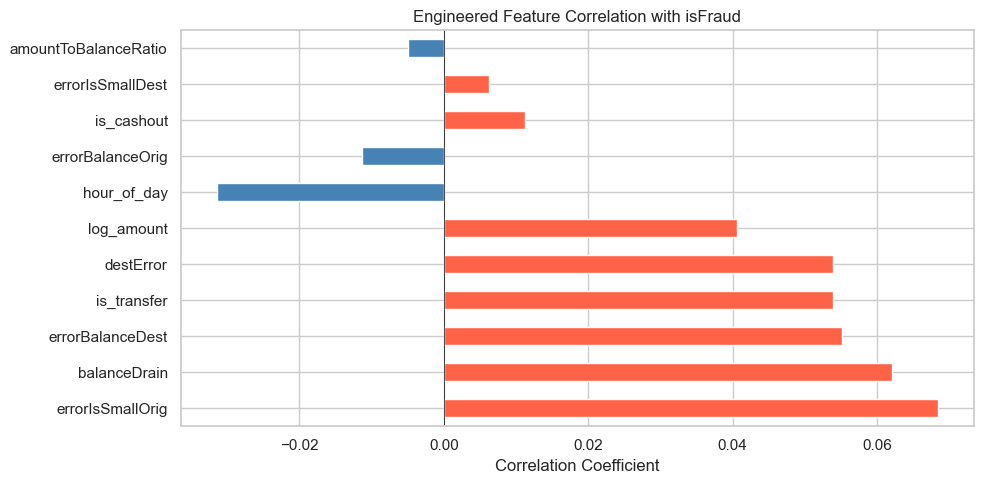

Feature correlation with isFraud (sorted by abs):
  errorIsSmallOrig          +0.0684
  balanceDrain              +0.0621
  errorBalanceDest          +0.0551
  is_transfer               +0.0539
  destError                 +0.0538
  log_amount                +0.0406
  hour_of_day               -0.0314
  errorBalanceOrig          -0.0113
  is_cashout                +0.0113
  errorIsSmallDest          +0.0063
  amountToBalanceRatio      -0.0049


In [84]:
corr_with_fraud = df[feature_cols + [target_col]].corr()[target_col].drop(target_col)
corr_with_fraud = corr_with_fraud.reindex(corr_with_fraud.abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 5))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_with_fraud]
corr_with_fraud.plot(kind='barh', color=colors)
plt.title('Engineered Feature Correlation with isFraud')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Feature correlation with isFraud (sorted by abs):')
for feat, val in corr_with_fraud.items():
    print(f'  {feat:25s} {val:+.4f}')

**Note:** Low correlation does NOT mean a feature is useless.
Non-linear relationships (e.g., balanceDrain) won't be captured by correlation
but can still be highly predictive in tree-based models.

## 3.3 Train / Test Split (Time-Based)

**Why time-based instead of random?**

In production, a model can only use past data to predict future transactions.
Random splitting allows the model to "see the future", leading to overly optimistic evaluation.

```
step 1 ------------ step ~594 --- step 743
       Train (80%)         Test (20%)
```

In [85]:
df = df.sort_values('step').reset_index(drop=True)

max_step = df['step'].max()
split_step = int(max_step * 0.8)

train_mask = df['step'] <= split_step
test_mask  = df['step'] > split_step

X_train = df.loc[train_mask, feature_cols]
y_train = df.loc[train_mask, target_col]
X_test  = df.loc[test_mask, feature_cols]
y_test  = df.loc[test_mask, target_col]

print(f'Split point: step {split_step} (out of {max_step})')
print(f'Train: {len(X_train):,} rows (fraud: {y_train.sum():,}, ratio: {y_train.mean()*100:.3f}%)')
print(f'Test:  {len(X_test):,} rows (fraud: {y_test.sum():,}, ratio: {y_test.mean()*100:.3f}%)')

Split point: step 594 (out of 743)
Train: 6,239,040 rows (fraud: 6,559, ratio: 0.105%)
Test:  123,580 rows (fraud: 1,654, ratio: 1.338%)


## 3.4 Save Processed Data

In [86]:
train_df = pd.concat([X_train, y_train], axis=1)
test_df  = pd.concat([X_test, y_test], axis=1)

train_df.to_csv('train_featured.csv', index=False)
test_df.to_csv('test_featured.csv', index=False)

print('Saved:')
print(f'  train_featured.csv ({len(train_df):,} rows, {train_df.shape[1]} cols)')
print(f'  test_featured.csv  ({len(test_df):,} rows, {test_df.shape[1]} cols)')
print()
print('Next step: Load these files in the modeling notebook.')

Saved:
  train_featured.csv (6,239,040 rows, 12 cols)
  test_featured.csv  (123,580 rows, 12 cols)

Next step: Load these files in the modeling notebook.


---
# 5. Modelling
---

---
## 5.1 Logistic Regression (Baseline)
---

## 4.2 Feature Scaling

**Why scale features for Logistic Regression?**

LR uses weights (coefficients) multiplied by feature values. If one feature ranges 0-1
and another ranges 0-10,000,000, the model struggles to find good weights.

StandardScaler transforms each feature to have mean=0 and std=1:
```
scaled_value = (value - mean) / std
```

**Important:** We fit the scaler on training data ONLY, then apply it to test data.
If we fit on all data, the model "sees" test data statistics → data leakage.

In [87]:
scaler = StandardScaler()

# fit_transform on train: learn mean/std from train, then scale train
X_train_scaled = scaler.fit_transform(X_train)

# transform on test: use the SAME mean/std from train to scale test
X_test_scaled = scaler.transform(X_test)

print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled shape:  {X_test_scaled.shape}')
print()
print('Example - first row before scaling:')
print(X_train.iloc[0].values.round(2))
print()
print('Example - first row after scaling:')
print(X_train_scaled[0].round(2))

X_train_scaled shape: (6239040, 11)
X_test_scaled shape:  (123580, 11)

Example - first row before scaling:
[0.00000e+00 0.00000e+00 0.00000e+00 9.83964e+03 1.00000e+00 0.00000e+00
 0.00000e+00 6.00000e-02 9.19000e+00 9.83964e+03 1.00000e+00]

Example - first row after scaling:
[-0.3  -0.74 -0.33 -0.1   1.92 -0.81 -0.56 -0.14 -0.91 -0.19 -3.31]


## 4.3 Train Logistic Regression

**Key parameter: `class_weight='balanced'`**

Without it, the model sees 99.87% non-fraud and learns to always predict "not fraud"
(high accuracy but catches zero fraud).

With `class_weight='balanced'`, the model automatically gives more importance to fraud samples:
```
weight_fraud     = total_samples / (2 * n_fraud)     ≈ 387
weight_non_fraud = total_samples / (2 * n_non_fraud)  ≈ 0.5
```
So each fraud sample counts ~774x more than a non-fraud sample during training.

In [88]:
lr_model = LogisticRegression(
    class_weight='balanced',  # Handle imbalance (Finding 1)
    max_iter=1000,            # Enough iterations to converge
    random_state=42,          # Reproducibility
)

lr_model.fit(X_train_scaled, y_train)
print('Logistic Regression trained.')

Logistic Regression trained.


## 4.4 Predictions

Two types of output from the model:
- `predict()` → hard label: 0 or 1 (using default threshold 0.5)
- `predict_proba()` → probability: 0.0 to 1.0 (how confident the model is)

We need both: hard labels for confusion matrix, probabilities for AUC and threshold tuning.

In [89]:
# Hard predictions (0 or 1)
y_pred_lr = lr_model.predict(X_test_scaled)

# Probability of being fraud (column index 1 = probability of class 1)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f'Predictions made on {len(y_pred_lr):,} test samples')
print(f'Predicted fraud count: {y_pred_lr.sum():,}')
print(f'Actual fraud count:    {y_test.sum():,}')

Predictions made on 123,580 test samples
Predicted fraud count: 1,644
Actual fraud count:    1,654


## 4.5 Evaluation: Classification Report

This shows Precision, Recall, and F1 for each class.

**How to read it:**

| Metric | What it answers | Formula |
|--------|----------------|---------|
| Precision | "Of all transactions I flagged as fraud, how many actually were?" | TP / (TP + FP) |
| Recall | "Of all actual fraud, how many did I catch?" | TP / (TP + FN) |
| F1 | "Balance between Precision and Recall" | 2 * P * R / (P + R) |

Where:
- TP = True Positive (correctly caught fraud)
- FP = False Positive (normal transaction wrongly flagged as fraud)
- FN = False Negative (fraud that was missed)

In [90]:
print('=== Logistic Regression — Classification Report ===')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Non-Fraud', 'Fraud']))

=== Logistic Regression — Classification Report ===

              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00    121926
       Fraud       1.00      0.99      1.00      1654

    accuracy                           1.00    123580
   macro avg       1.00      1.00      1.00    123580
weighted avg       1.00      1.00      1.00    123580



## 4.6 Evaluation: Confusion Matrix

A 2x2 grid showing exactly what the model got right and wrong.

```
                  Predicted
                  Non-Fraud    Fraud
Actual Non-Fraud  [  TN    |   FP  ]   ← FP = false alarm (annoying but not dangerous)
Actual Fraud      [  FN    |   TP  ]   ← FN = missed fraud (dangerous! money lost)
```

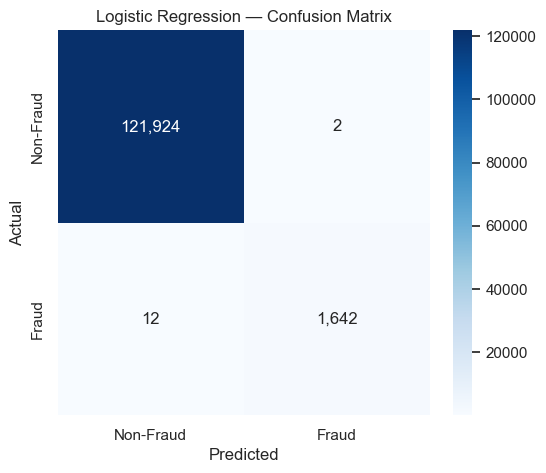

True Negatives  (correct non-fraud): 121,924
False Positives (false alarms):      2
False Negatives (missed fraud):      12
True Positives  (caught fraud):      1,642


In [91]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correct non-fraud): {tn:,}')
print(f'False Positives (false alarms):      {fp:,}')
print(f'False Negatives (missed fraud):      {fn:,}')
print(f'True Positives  (caught fraud):      {tp:,}')

## 4.7 Evaluation: ROC Curve & AUC

**ROC Curve** plots True Positive Rate vs False Positive Rate at every possible threshold.

**AUC** (Area Under the Curve) = one number summarizing the model's ability to rank fraud higher than non-fraud.
- AUC = 1.0 → perfect model
- AUC = 0.5 → random guessing (useless)
- AUC > 0.8 → generally considered good

AUC Score: 0.9997


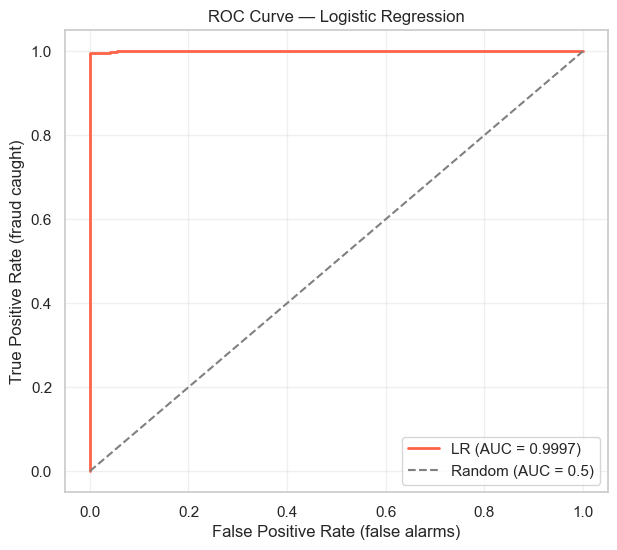

In [92]:
# Calculate AUC
auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f'AUC Score: {auc_lr:.4f}')

# Plot ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='tomato', linewidth=2, label=f'LR (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate (false alarms)')
plt.ylabel('True Positive Rate (fraud caught)')
plt.title('ROC Curve — Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4.8 Evaluation: Precision-Recall Curve

For imbalanced data, PR curve is MORE informative than ROC curve.

It shows the trade-off: if you want to catch more fraud (higher recall),
you'll get more false alarms (lower precision).

The **best threshold** is where F1 is maximized (balance point).

Best threshold: 0.9815
Best F1 at that threshold: 0.9964
Precision at best threshold: 1.0000
Recall at best threshold:    0.9927


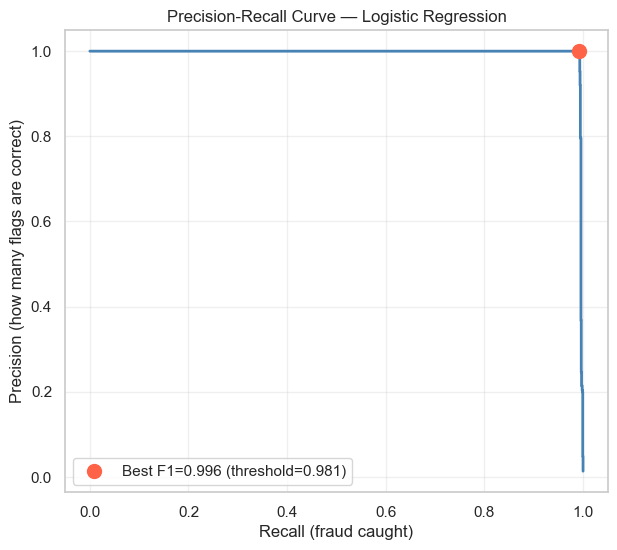

In [93]:
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_prob_lr)

# Find the threshold that maximizes F1
f1_scores = 2 * precision_vals[:-1] * recall_vals[:-1] / (precision_vals[:-1] + recall_vals[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds_pr[best_idx]
best_f1 = f1_scores[best_idx]

print(f'Best threshold: {best_threshold:.4f}')
print(f'Best F1 at that threshold: {best_f1:.4f}')
print(f'Precision at best threshold: {precision_vals[best_idx]:.4f}')
print(f'Recall at best threshold:    {recall_vals[best_idx]:.4f}')

# Plot
plt.figure(figsize=(7, 6))
plt.plot(recall_vals, precision_vals, color='steelblue', linewidth=2)
plt.scatter(recall_vals[best_idx], precision_vals[best_idx],
            color='tomato', s=100, zorder=5,
            label=f'Best F1={best_f1:.3f} (threshold={best_threshold:.3f})')
plt.xlabel('Recall (fraud caught)')
plt.ylabel('Precision (how many flags are correct)')
plt.title('Precision-Recall Curve — Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4.9 Feature Weights (What LR Learned)

Logistic Regression assigns a weight (coefficient) to each feature.
- Positive weight → higher value of this feature → more likely fraud
- Negative weight → higher value of this feature → less likely fraud
- Larger absolute weight → feature matters more

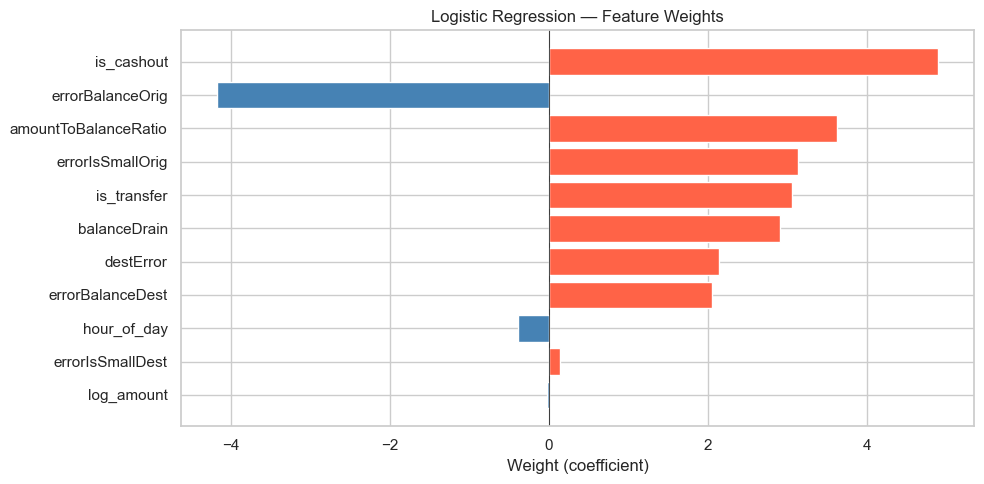

Feature weights (sorted by absolute value):
  is_cashout                +4.8963  → more fraud
  errorBalanceOrig          -4.1803  → less fraud
  amountToBalanceRatio      +3.6196  → more fraud
  errorIsSmallOrig          +3.1342  → more fraud
  is_transfer               +3.0543  → more fraud
  balanceDrain              +2.9135  → more fraud
  destError                 +2.1389  → more fraud
  errorBalanceDest          +2.0493  → more fraud
  hour_of_day               -0.3883  → less fraud
  errorIsSmallDest          +0.1335  → more fraud
  log_amount                -0.0243  → less fraud


In [94]:
# Get coefficients and sort by absolute value
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'weight': lr_model.coef_[0]
}).sort_values('weight', key=abs, ascending=False)

# Plot
plt.figure(figsize=(10, 5))
colors = ['tomato' if w > 0 else 'steelblue' for w in coef_df['weight']]
plt.barh(coef_df['feature'], coef_df['weight'], color=colors)
plt.xlabel('Weight (coefficient)')
plt.title('Logistic Regression — Feature Weights')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Feature weights (sorted by absolute value):')
for _, row in coef_df.iterrows():
    direction = '→ more fraud' if row['weight'] > 0 else '→ less fraud'
    print(f"  {row['feature']:25s} {row['weight']:+.4f}  {direction}")

## 4.10 Baseline Summary

| Metric | Value |
|--------|-------|
| AUC | (see output above) |
| Best F1 | (see output above) |
| Best Threshold | (see output above) |

**What we learned from the baseline:**
- LR is a linear model — it can only draw a straight line to separate fraud from non-fraud
- The feature weights tell us which EDA insights the model found most useful
- This sets our baseline: any future model must beat these numbers to be worth the complexity

---
## 5.2 XGBoost (Main Model)
---

## 5.2 Train XGBoost

**Key parameter: `scale_pos_weight`**

Same idea as LR's `class_weight='balanced'` — tell the model that fraud samples are more important.

`scale_pos_weight = n_non_fraud / n_fraud`

This means: "treat each fraud sample as if there were `scale_pos_weight` copies of it."

**Note:** XGBoost does NOT need feature scaling (unlike LR).
Tree-based models split on feature values directly, so scale doesn't matter.
We use the original `X_train` and `X_test`, not the scaled versions.

In [95]:
# Calculate class imbalance ratio
n_non_fraud = (y_train == 0).sum()
n_fraud = (y_train == 1).sum()
ratio = n_non_fraud / n_fraud
print(f'Non-fraud: {n_non_fraud:,}  |  Fraud: {n_fraud:,}  |  Ratio: {ratio:.1f}')

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=ratio,     # Handle imbalance
    n_estimators=200,           # Number of trees (more trees = more complex, but slower)
    max_depth=6,                # Max depth per tree (prevents overfitting)
    learning_rate=0.1,          # How much each tree contributes (smaller = more conservative)
    eval_metric='aucpr',        # Optimize for AUC of Precision-Recall curve
    random_state=42,
    use_label_encoder=False,
)

# XGBoost uses UNSCALED features (tree models don't need scaling)
xgb_model.fit(X_train, y_train)
print('XGBoost trained.')

Non-fraud: 6,232,481  |  Fraud: 6,559  |  Ratio: 950.2


/Users/zhengwei/Downloads/nus/Y3S2/is4228/is4228-project---fraud-detection/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [16:18:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost trained.


## 5.3 XGBoost Predictions & Classification Report

In [96]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print('=== XGBoost — Classification Report ===')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Non-Fraud', 'Fraud']))

=== XGBoost — Classification Report ===

              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00    121926
       Fraud       0.99      1.00      0.99      1654

    accuracy                           1.00    123580
   macro avg       0.99      1.00      1.00    123580
weighted avg       1.00      1.00      1.00    123580



## 5.4 XGBoost Confusion Matrix

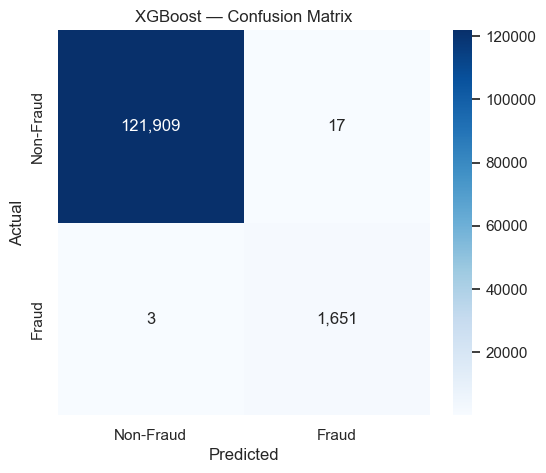

True Negatives  (correct non-fraud): 121,909
False Positives (false alarms):      17
False Negatives (missed fraud):      3
True Positives  (caught fraud):      1,651


In [97]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt=',', cmap='Blues',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost — Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm_xgb.ravel()
print(f'True Negatives  (correct non-fraud): {tn:,}')
print(f'False Positives (false alarms):      {fp:,}')
print(f'False Negatives (missed fraud):      {fn:,}')
print(f'True Positives  (caught fraud):      {tp:,}')

## 5.5 XGBoost ROC & PR Curves

XGBoost AUC: 1.0000  (LR was 0.9997)


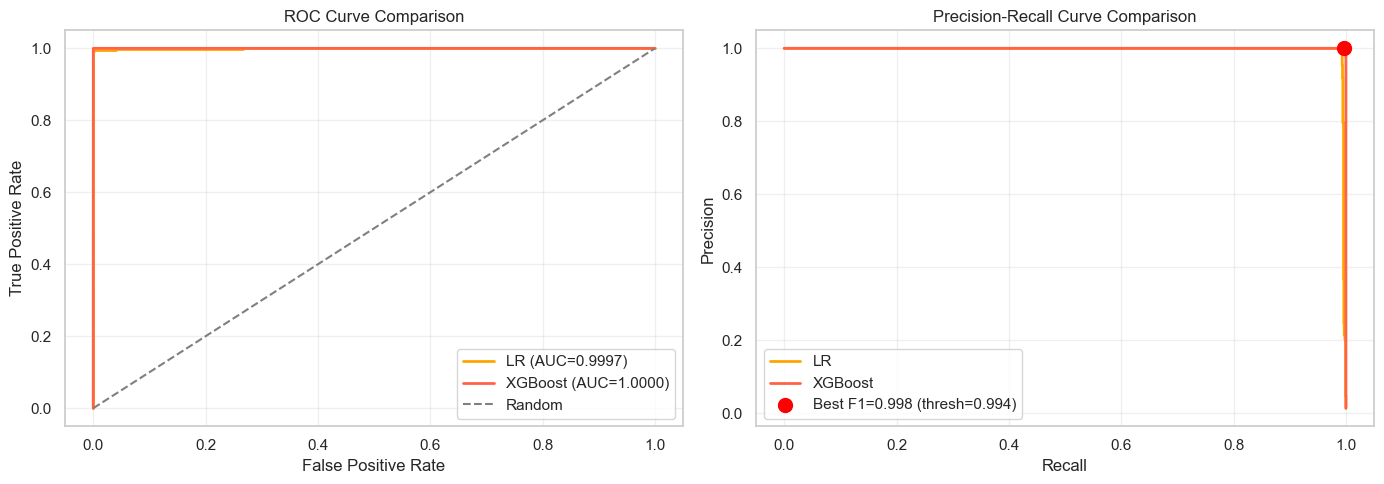

XGBoost best threshold: 0.9942
XGBoost best F1:        0.9985


In [98]:
# AUC
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f'XGBoost AUC: {auc_xgb:.4f}  (LR was {auc_lr:.4f})')

# ROC curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ROC
axes[0].plot(fpr, tpr, color='orange', linewidth=2, label=f'LR (AUC={auc_lr:.4f})')
axes[0].plot(fpr_xgb, tpr_xgb, color='tomato', linewidth=2, label=f'XGBoost (AUC={auc_xgb:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: PR curve
prec_xgb, rec_xgb, thresh_xgb = precision_recall_curve(y_test, y_prob_xgb)
f1_xgb = 2 * prec_xgb[:-1] * rec_xgb[:-1] / (prec_xgb[:-1] + rec_xgb[:-1] + 1e-8)
best_idx_xgb = np.argmax(f1_xgb)
best_thresh_xgb = thresh_xgb[best_idx_xgb]
best_f1_xgb = f1_xgb[best_idx_xgb]

axes[1].plot(recall_vals, precision_vals, color='orange', linewidth=2, label='LR')
axes[1].plot(rec_xgb, prec_xgb, color='tomato', linewidth=2, label='XGBoost')
axes[1].scatter(rec_xgb[best_idx_xgb], prec_xgb[best_idx_xgb],
                color='red', s=100, zorder=5,
                label=f'Best F1={best_f1_xgb:.3f} (thresh={best_thresh_xgb:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'XGBoost best threshold: {best_thresh_xgb:.4f}')
print(f'XGBoost best F1:        {best_f1_xgb:.4f}')

## 5.6 XGBoost Feature Importance

Unlike LR which uses linear weights, XGBoost measures feature importance by
how much each feature **reduces prediction error** across all trees.

Higher importance = the model relied on this feature more to make decisions.

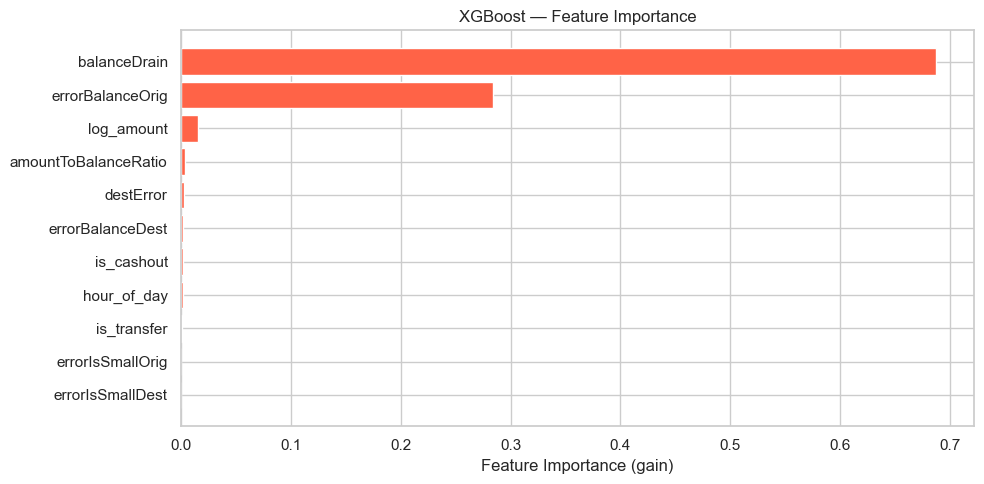

Feature importance ranking:
  1. balanceDrain              0.6875
  2. errorBalanceOrig          0.2842
  3. log_amount                0.0152
  4. amountToBalanceRatio      0.0039
  5. destError                 0.0026
  6. errorBalanceDest          0.0021
  7. is_cashout                0.0020
  8. hour_of_day               0.0015
  9. is_transfer               0.0010
  10. errorIsSmallOrig          0.0000
  11. errorIsSmallDest          0.0000


In [99]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(importance['feature'], importance['importance'], color='tomato')
plt.xlabel('Feature Importance (gain)')
plt.title('XGBoost — Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Feature importance ranking:')
for i, (_, row) in enumerate(importance.iterrows(), 1):
    print(f"  {i}. {row['feature']:25s} {row['importance']:.4f}")

---
# Part 6: Modeling — Isolation Forest (Anomaly Detection)

**How is this different from LR and XGBoost?**

| | LR & XGBoost | Isolation Forest |
|---|---|---|
| Type | Supervised (uses labels) | Unsupervised (ignores labels) |
| Learns | "What does known fraud look like?" | "What looks different from normal?" |
| Strength | Precise on known fraud patterns | Can detect NEW fraud patterns never seen before |

**How it works:**
- Randomly picks a feature and a split value
- Repeats until each data point is isolated
- Anomalies are isolated in fewer splits (they're "easy to separate")
- Normal points need many splits (they're "buried in the crowd")

**Output:** An anomaly score (not a probability). More negative = more anomalous.

---

---
## 5.3 Isolation Forest (Anomaly Detection)
---

### Train Isolation Forest

In [100]:
if_model = IsolationForest(
    contamination=0.002,   # Expected anomaly rate (~0.2%, slightly above actual 0.13%)
    n_estimators=200,      # Number of isolation trees
    max_samples='auto',    # Subsample size for each tree
    random_state=42,
)

# Train on features only — NO labels used
if_model.fit(X_train)
print('Isolation Forest trained (unsupervised — no labels used).')

Isolation Forest trained (unsupervised — no labels used).


## 6.2 Isolation Forest Predictions

Isolation Forest outputs:
- `predict()` → 1 (normal) or -1 (anomaly)
- `score_samples()` → anomaly score (more negative = more anomalous)

We convert -1/1 to 1/0 to match our isFraud format (1 = fraud).

In [101]:
# Raw predictions: 1 = normal, -1 = anomaly
if_raw = if_model.predict(X_test)

# Convert: -1 (anomaly) -> 1 (fraud), 1 (normal) -> 0 (not fraud)
y_pred_if = (if_raw == -1).astype(int)

# Anomaly scores (more negative = more anomalous)
if_scores = if_model.score_samples(X_test)

# Convert to "fraud score": negate so higher = more suspicious
# Then normalize to 0-1 range for comparability
fraud_score_if = -if_scores
fraud_score_if = (fraud_score_if - fraud_score_if.min()) / (fraud_score_if.max() - fraud_score_if.min())

print(f'Predicted anomalies: {y_pred_if.sum():,}')
print(f'Actual fraud:        {y_test.sum():,}')

Predicted anomalies: 297
Actual fraud:        1,654


## 6.3 Isolation Forest Evaluation

=== Isolation Forest — Classification Report ===

              precision    recall  f1-score   support

   Non-Fraud       0.99      1.00      0.99    121926
       Fraud       0.57      0.10      0.17      1654

    accuracy                           0.99    123580
   macro avg       0.78      0.55      0.58    123580
weighted avg       0.98      0.99      0.98    123580



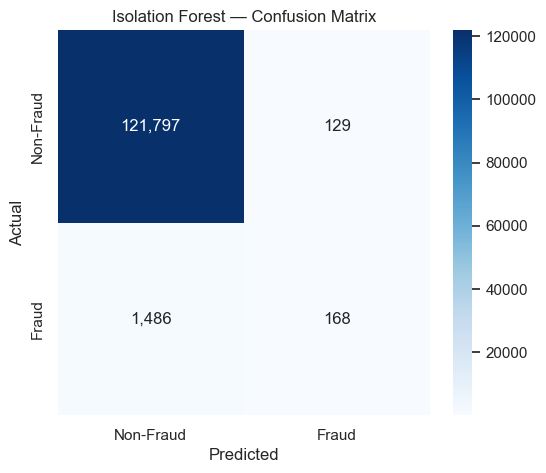

True Negatives  (correct non-fraud): 121,797
False Positives (false alarms):      129
False Negatives (missed fraud):      1,486
True Positives  (caught fraud):      168


In [102]:
print('=== Isolation Forest — Classification Report ===')
print()
print(classification_report(y_test, y_pred_if, target_names=['Non-Fraud', 'Fraud']))

# Confusion matrix
cm_if = confusion_matrix(y_test, y_pred_if)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_if, annot=True, fmt=',', cmap='Blues',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Isolation Forest — Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm_if.ravel()
print(f'True Negatives  (correct non-fraud): {tn:,}')
print(f'False Positives (false alarms):      {fp:,}')
print(f'False Negatives (missed fraud):      {fn:,}')
print(f'True Positives  (caught fraud):      {tp:,}')

## 6.4 Anomaly Score Distribution

Let's see how well the anomaly score separates fraud from non-fraud.
If the model works, fraud transactions should have higher anomaly scores.

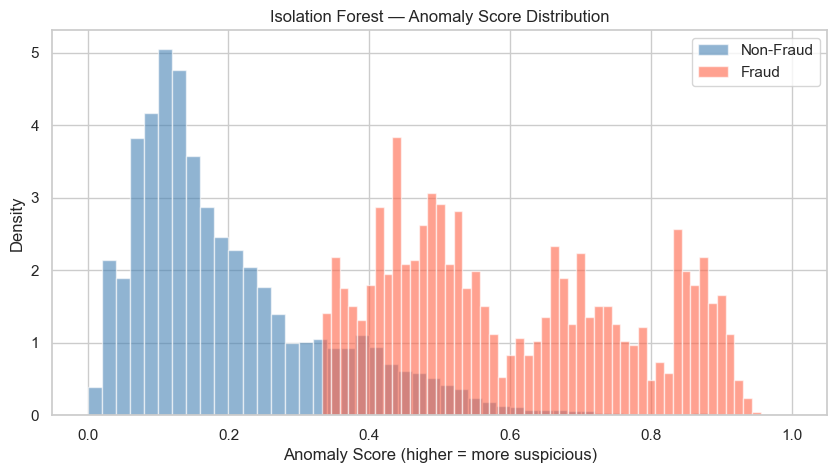

Isolation Forest AUC: 0.9607


In [103]:
plt.figure(figsize=(10, 5))
plt.hist(fraud_score_if[y_test == 0], bins=50, alpha=0.6, label='Non-Fraud', color='steelblue', density=True)
plt.hist(fraud_score_if[y_test == 1], bins=50, alpha=0.6, label='Fraud', color='tomato', density=True)
plt.xlabel('Anomaly Score (higher = more suspicious)')
plt.ylabel('Density')
plt.title('Isolation Forest — Anomaly Score Distribution')
plt.legend()
plt.show()

# AUC using anomaly scores
auc_if = roc_auc_score(y_test, fraud_score_if)
print(f'Isolation Forest AUC: {auc_if:.4f}')

---
## 5.4 SVM (Support Vector Machine)
---

### Train SVM

SVM is sensitive to feature scaling, so we reuse the scaled features from the Logistic Regression section.
We use `SVC` with `probability=True` to enable probability estimates for the model comparison.

In [104]:
print('Training SVM model...')
print('Note: Using linear kernel for efficiency with large dataset')
print('This may take 5-15 minutes depending on your hardware...')

svm_model = SVC(
    kernel='linear',
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    C=0.1,
    probability=True,        # Enable probability estimates
    verbose=True,
)

# Fit on the SAME scaled features used for Logistic Regression
svm_model.fit(X_train_scaled, y_train)
print('\nSVM model trained successfully!')

Training SVM model...
Note: Using linear kernel for efficiency with large dataset
This may take 5-15 minutes depending on your hardware...
[LibSVM]WARN: libsvm Solver reached max_iter
optimization finished, #iter = 1000
obj = -99.960742, rho = 2.390890
nSV = 1007, nBSV = 998
Total nSV = 1007
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 1000
obj = -99.996814, rho = 0.389462
nSV = 1010, nBSV = 999
Total nSV = 1010
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 1000
obj = -99.955322, rho = 2.480811
nSV = 1007, nBSV = 998
Total nSV = 1007
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 1000
obj = -99.865492, rho = 1.049349
nSV = 1009, nBSV = 998
Total nSV = 1009
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 1000
obj = -100.063194, rho = -0.287503
nSV = 1007, nBSV = 1000
Total nSV = 1007
WARN: libsvm Solver reached max_iter
optimization finished, #iter = 1000
obj = -94.742130, rho = 0.523385
nSV = 996, nBS

/Users/zhengwei/Downloads/nus/Y3S2/is4228/is4228-project---fraud-detection/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


### SVM Evaluation

In [105]:
# Predictions
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]  # probability of fraud class

# Metrics
auc_svm = roc_auc_score(y_test, y_prob_svm)

print('=== SVM — Classification Report ===')
print(classification_report(y_test, y_pred_svm, target_names=['Non-Fraud', 'Fraud']))
print(f'AUC Score: {auc_svm:.4f}')

=== SVM — Classification Report ===
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.27      0.43    121926
       Fraud       0.02      0.94      0.03      1654

    accuracy                           0.28    123580
   macro avg       0.51      0.61      0.23    123580
weighted avg       0.98      0.28      0.42    123580

AUC Score: 0.7603


---
# 6. Model Evaluation & Comparison
---

## 6.1 Side-by-Side Comparison

In [106]:
# Collect metrics for all 4 models
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'Isolation Forest', 'SVM'],
    'AUC': [
        auc_lr,
        auc_xgb,
        auc_if,
        auc_svm,
    ],
    'Recall (fraud caught)': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_if),
        recall_score(y_test, y_pred_svm),
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_xgb, zero_division=0),
        precision_score(y_test, y_pred_if, zero_division=0),
        precision_score(y_test, y_pred_svm, zero_division=0),
    ],
    'F1': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_if),
        f1_score(y_test, y_pred_svm),
    ],
}).round(4)

print('=== Model Comparison ===')
print()
print(results.to_string(index=False))

=== Model Comparison ===

              Model    AUC  Recall (fraud caught)  Precision     F1
Logistic Regression 0.9997                 0.9927     0.9988 0.9958
            XGBoost 1.0000                 0.9982     0.9898 0.9940
   Isolation Forest 0.9607                 0.1016     0.5657 0.1722
                SVM 0.7603                 0.9420     0.0172 0.0338


## 6.2 Visual Comparison

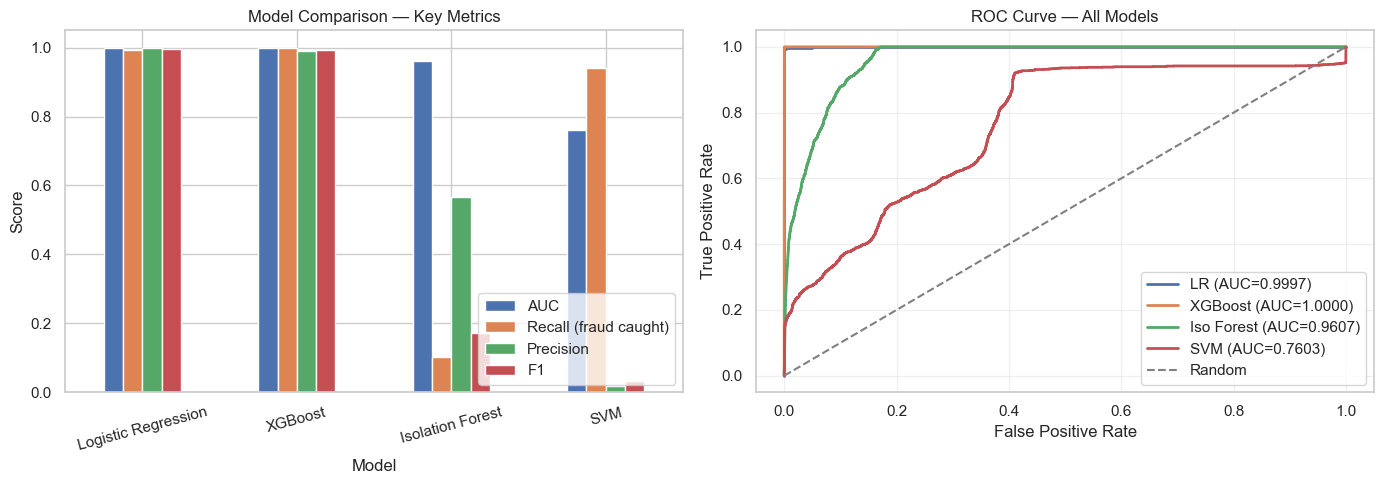

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Bar chart of metrics
metrics_to_plot = results.set_index('Model')[['AUC', 'Recall (fraud caught)', 'Precision', 'F1']]
metrics_to_plot.plot(kind='bar', ax=axes[0], rot=15, edgecolor='white')
axes[0].set_title('Model Comparison — Key Metrics')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right')

# Right: ROC curves for all 4 models
fpr_if, tpr_if, _ = roc_curve(y_test, fraud_score_if)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
axes[1].plot(fpr, tpr, linewidth=2, label=f'LR (AUC={auc_lr:.4f})')
axes[1].plot(fpr_xgb, tpr_xgb, linewidth=2, label=f'XGBoost (AUC={auc_xgb:.4f})')
axes[1].plot(fpr_if, tpr_if, linewidth=2, label=f'Iso Forest (AUC={auc_if:.4f})')
axes[1].plot(fpr_svm, tpr_svm, linewidth=2, label=f'SVM (AUC={auc_svm:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — All Models')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7.3 Decision Engine — Mapping XGBoost Score to Actions

The best model (XGBoost) outputs a fraud probability (0 to 1).
We map it to business decisions using the optimal threshold found earlier:

| Probability | Risk Level | Action |
|------------|------------|--------|
| > 0.7 | High | Block transaction |
| 0.3 — 0.7 | Medium | Flag for manual review |
| < 0.3 | Low | Approve transaction |

These thresholds can be adjusted based on business needs (catch more fraud vs fewer false alarms).

In [108]:
# Apply decision engine to test set
def get_decision(prob):
    if prob > 0.7:
        return 'BLOCK'
    elif prob > 0.3:
        return 'FLAG'
    else:
        return 'APPROVE'

decisions = pd.Series(y_prob_xgb).apply(get_decision)

print('=== Decision Engine Output ===')
print()
print('Decision distribution:')
print(decisions.value_counts())
print()

# How many actual frauds fall into each category?
decision_df = pd.DataFrame({
    'decision': decisions.values,
    'actual_fraud': y_test.values
})

print('Actual fraud by decision:')
fraud_by_decision = decision_df.groupby('decision')['actual_fraud'].agg(['sum', 'count'])
fraud_by_decision.columns = ['actual_fraud', 'total_transactions']
fraud_by_decision['fraud_rate'] = (fraud_by_decision['actual_fraud'] / fraud_by_decision['total_transactions'] * 100).round(2)
print(fraud_by_decision)
print()

total_fraud = y_test.sum()
blocked_fraud = decision_df[decision_df['decision'] == 'BLOCK']['actual_fraud'].sum()
flagged_fraud = decision_df[decision_df['decision'] == 'FLAG']['actual_fraud'].sum()
approved_fraud = decision_df[decision_df['decision'] == 'APPROVE']['actual_fraud'].sum()

print(f'Total fraud in test set: {total_fraud:,}')
print(f'  Blocked (auto-stopped):   {blocked_fraud:,} ({blocked_fraud/total_fraud*100:.1f}%)')
print(f'  Flagged (sent to review): {flagged_fraud:,} ({flagged_fraud/total_fraud*100:.1f}%)')
print(f'  Approved (missed):        {approved_fraud:,} ({approved_fraud/total_fraud*100:.1f}%)')

=== Decision Engine Output ===

Decision distribution:
APPROVE    121905
BLOCK        1662
FLAG           13
Name: count, dtype: int64

Actual fraud by decision:
          actual_fraud  total_transactions  fraud_rate
decision                                              
APPROVE              0              121905        0.00
BLOCK             1649                1662       99.22
FLAG                 5                  13       38.46

Total fraud in test set: 1,654
  Blocked (auto-stopped):   1,649 (99.7%)
  Flagged (sent to review): 5 (0.3%)
  Approved (missed):        0 (0.0%)


---
# 7. Model Export
---

## 7.1 Save Models

Save all trained models and artifacts using `joblib` for deployment.

In [109]:
# Define output directory (same as notebook directory)
# Convert string to a Path object
MODEL_DIR = Path('../../models') 

# Ensure the directory exists
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save models as .joblib (original filenames)
joblib.dump(xgb_model, MODEL_DIR / 'paysim_xgb_fraud_model.joblib')
joblib.dump(if_model,  MODEL_DIR / 'paysim_isolation_forest_model.joblib')
joblib.dump(svm_model, MODEL_DIR / 'paysim_svm_model.joblib')
joblib.dump(scaler,    MODEL_DIR / 'paysim_scaler.joblib')

# [NEW] Save artifacts.joblib with features and threshold
joblib.dump(
    {'threshold': 0.7, 'features': feature_cols},
    MODEL_DIR / 'paysim_artifacts.joblib'
)

print('Models and artifacts saved:')
print(f'  {MODEL_DIR / "paysim_xgb_fraud_model.joblib"}       (main model)')
print(f'  {MODEL_DIR / "paysim_isolation_forest_model.joblib"} (anomaly detection)')
print(f'  {MODEL_DIR / "paysim_svm_model.joblib"}              (SVM model)')
print(f'  {MODEL_DIR / "paysim_scaler.joblib"}                 (feature scaler)')
print(f'  {MODEL_DIR / "paysim_artifacts.joblib"}              (threshold and features)')
print()
print(f'Feature columns expected: {feature_cols}')

Models and artifacts saved:
  ../../models/paysim_xgb_fraud_model.joblib       (main model)
  ../../models/paysim_isolation_forest_model.joblib (anomaly detection)
  ../../models/paysim_svm_model.joblib              (SVM model)
  ../../models/paysim_scaler.joblib                 (feature scaler)
  ../../models/paysim_artifacts.joblib              (threshold and features)

Feature columns expected: ['is_transfer', 'is_cashout', 'errorBalanceOrig', 'errorBalanceDest', 'errorIsSmallOrig', 'errorIsSmallDest', 'balanceDrain', 'amountToBalanceRatio', 'log_amount', 'destError', 'hour_of_day']


---
## Final Summary

### Pipeline Completed:
```
Raw Data (6.3M rows)
  → EDA (7 key findings)
  → Feature Engineering (11 features, all traced to EDA)
  → Time-based Train/Test Split
  → 4 Models Trained & Evaluated
  → Decision Engine (Block / Flag / Approve)
  → Models Saved for Dashboard
```

### Model Roles:
| Model | Role | Strength |
|-------|------|----------|
| Logistic Regression | Baseline | Proves our features work (even a simple model can detect fraud) |
| XGBoost | Main model | Best overall performance, captures non-linear patterns |
| Isolation Forest | Supplement | Catches unknown/new fraud patterns without needing labels |
| SVM | Alternative | Linear decision boundary with probabilistic outputs |

### Saved Artifacts:
| File | Purpose |
|------|---------|
| `train_featured.csv` | Training data with engineered features |
| `test_featured.csv` | Test data with engineered features |
| `paysim_xgb_fraud_model.joblib` | XGBoost model for deployment |
| `paysim_isolation_forest_model.joblib` | Isolation Forest for anomaly detection |
| `paysim_svm_model.joblib` | SVM model |
| `paysim_scaler.joblib` | Feature scaler (for LR/SVM preprocessing) |
| `paysim_artifacts.joblib` | Feature scaler (for LR/SVM preprocessing) |
